<a href="https://colab.research.google.com/github/andiandiandika3-prog/Mechine-Learning/blob/main/2_Xgboost/hypertunning%20grid%20%26%20random.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bangun Model

## Install Pakcage xgboost

In [77]:
if (!require(xgboost)){
  install.packages("xgboost")
}

library(xgboost)

## Muat data

In [78]:
if (!require(modeldata)){
  install.packages("modeldata")
}

library(modeldata)

df <- stackoverflow # data bawaan

cat("------------------------------------------------------------------------------","\n")
cat("Struktur Data","\n")
cat("------------------------------------------------------------------------------","\n")
str(df)


------------------------------------------------------------------------------ 
Struktur Data 
------------------------------------------------------------------------------ 
tibble [5,594 × 21] (S3: tbl_df/tbl/data.frame)
 $ Country                             : Factor w/ 5 levels "Canada","Germany",..: 4 5 5 2 3 5 5 2 5 2 ...
 $ Salary                              : num [1:5594] 100000 130000 175000 64516 6636 ...
 $ YearsCodedJob                       : int [1:5594] 20 20 16 4 1 1 13 4 7 17 ...
 $ OpenSource                          : num [1:5594] 0 1 0 0 0 0 0 1 1 1 ...
 $ Hobby                               : num [1:5594] 1 1 1 0 1 1 1 0 1 1 ...
 $ CompanySizeNumber                   : num [1:5594] 5000 1000 10000 1000 5000 20 20 5000 20 20 ...
 $ Remote                              : Factor w/ 2 levels "Remote","Not remote": 1 1 2 2 2 2 2 2 2 2 ...
 $ CareerSatisfaction                  : int [1:5594] 8 9 7 9 5 8 7 7 8 9 ...
 $ Data_scientist                      : num [1:5594] 0

Persiapan Data

In [79]:
library(dplyr)

y <- as.numeric(df$Remote)-1 # Buat Menjadi Kategori 1 dan 0
x <- df %>% select(-Remote)

cat("------------------------------------------------------------------------------","\n")
cat("Struktur Data prediktor","\n")
cat("------------------------------------------------------------------------------","\n")
str(x)

------------------------------------------------------------------------------ 
Struktur Data prediktor 
------------------------------------------------------------------------------ 
tibble [5,594 × 20] (S3: tbl_df/tbl/data.frame)
 $ Country                             : Factor w/ 5 levels "Canada","Germany",..: 4 5 5 2 3 5 5 2 5 2 ...
 $ Salary                              : num [1:5594] 100000 130000 175000 64516 6636 ...
 $ YearsCodedJob                       : int [1:5594] 20 20 16 4 1 1 13 4 7 17 ...
 $ OpenSource                          : num [1:5594] 0 1 0 0 0 0 0 1 1 1 ...
 $ Hobby                               : num [1:5594] 1 1 1 0 1 1 1 0 1 1 ...
 $ CompanySizeNumber                   : num [1:5594] 5000 1000 10000 1000 5000 20 20 5000 20 20 ...
 $ CareerSatisfaction                  : int [1:5594] 8 9 7 9 5 8 7 7 8 9 ...
 $ Data_scientist                      : num [1:5594] 0 0 0 0 0 0 0 0 0 0 ...
 $ Database_administrator              : num [1:5594] 0 0 0 0 0 0 0 0 0 0 

Dalam Xgboost semua faktor harus dijadikan Dummy variabel




In [80]:
if (!require(fastDummies)){
  install.packages("fastDummies")
}
library(fastDummies)

#dummy_cols(
#       .data,
#       select_columns = NULL,
#       remove_first_dummy = FALSE,
#       remove_most_frequent_dummy = FALSE,
#       ignore_na = FALSE,
#       split = NULL,
#       remove_selected_columns = FALSE,
#       omit_colname_prefix = FALSE,
#       return_generated_variables = FALSE
#    )

x <- dummy_cols(x, remove_first_dummy = T)
x <- x %>% select(-Country)

## Parameter Xgboost

| Parameter             | Macam Fungsi (Opsi)                                              | Default (R)      | Keterangan                         |
| --------------------- | ---------------------------------------------------------------- | ---------------- | ---------------------------------- |
| booster               | gbtree, gblinear, dart                                           | gbtree           | Tipe model (tree/linear)           |
| objective             | reg:squarederror, binary:logistic, multi:softmax, multi:softprob | reg:squarederror | Fungsi tujuan (loss function)      |
| eval_metric           | rmse, mae, logloss, error, auc                                   | rmse             | Metrik evaluasi                    |
| eta                   | 0 – 1                                                            | 0.3              | Learning rate                      |
| max_depth             | 1 – ∞ (umumnya 3–10)                                             | 6                | Kedalaman tree                     |
| min_child_weight      | 0 – ∞                                                            | 1                | Minimum weight per leaf            |
| gamma                 | 0 – ∞                                                            | 0                | Minimum loss reduction untuk split |
| subsample             | 0 – 1                                                            | 1                | Proporsi data                      |
| colsample_bytree      | 0 – 1                                                            | 1                | Proporsi fitur                     |
| lambda                | 0 – ∞                                                            | 1                | L2 regularization                  |
| alpha                 | 0 – ∞                                                            | 0                | L1 regularization                  |
| scale_pos_weight      | 0 – ∞                                                            | 1                | Handling imbalance                 |
| nrounds               | integer > 0                                                      | 100              | Jumlah iterasi boosting            |
| early_stopping_rounds | integer > 0                                                      | NULL             | Early stopping                     |


| Opsi             | Fungsi                                                                                                                             |
| ---------------- | ---------------------------------------------------------------------------------------------------------------------------------- |
| gbtree           | Menggunakan pohon keputusan sebagai base learner. Ini opsi paling umum di XGBoost untuk klasifikasi dan regresi.                   |
| gblinear         | Menggunakan model linear sebagai base learner, jadi cocok kalau hubungan antar fitur cenderung linear.                             |
| dart             | Menggunakan pohon keputusan dengan dropout. Tujuannya untuk mengurangi overfitting dengan menjatuhkan sebagian tree saat training. |
| reg:squarederror | Regresi dengan squared loss. Dipakai untuk prediksi nilai kontinu.                                                                 |
| binary:logistic  | Klasifikasi biner dengan output probabilitas antara 0 dan 1.                                                                       |
| multi:softmax    | Klasifikasi multikelas dengan output label kelas langsung. Biasanya perlu num_class.                                               |
| multi:softprob   | Klasifikasi multikelas dengan output probabilitas tiap kelas. Juga perlu num_class.                                                |

In [81]:
set.seed(1502)
param <- list(
  eval_metric = "auc",
  objective = "binary:logistic"
)

# Running Model

In [82]:
dtrain <- xgb.DMatrix(data = as.matrix(x), label = y)

model <- xgb.train(
  params = param,
  data = dtrain,
  nrounds = 20,
  evals = list(train = dtrain), #evaluasi yang ingin ditampilkan
  print_every_n =1 # tampilkan setiap iterasi
)

[1]	train-auc:0.767418 
[2]	train-auc:0.785779 
[3]	train-auc:0.794311 
[4]	train-auc:0.804662 
[5]	train-auc:0.816453 
[6]	train-auc:0.827194 
[7]	train-auc:0.837382 
[8]	train-auc:0.842544 
[9]	train-auc:0.852386 
[10]	train-auc:0.860178 
[11]	train-auc:0.863803 
[12]	train-auc:0.870351 
[13]	train-auc:0.873537 
[14]	train-auc:0.876672 
[15]	train-auc:0.882491 
[16]	train-auc:0.886357 
[17]	train-auc:0.890437 
[18]	train-auc:0.895712 
[19]	train-auc:0.901441 
[20]	train-auc:0.904475 


## Shap

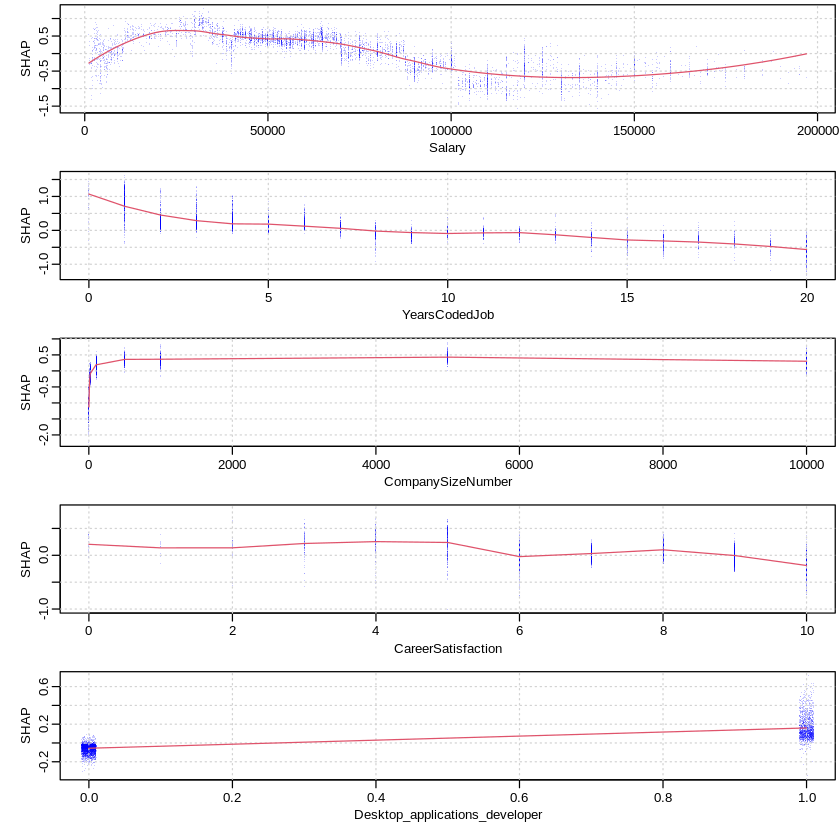

In [83]:
xgb.plot.shap(data = as.matrix(x),
              model = model,
              top_n = 5)

# Model dengan Traning dan testing
## Membuat data train dan testing

In [84]:
set.seed(123)

train_index <- sample(1:nrow(df), 0.8*nrow(df))
x_train <- x[train_index,]
x_test <- x[-train_index,]

y_train <- y[train_index]
y_test <- y[-train_index]

cat("----------------------------------------------------","\n")
cat("Panjang Data train dan test ","\n")
cat("----------------------------------------------------","\n")
cat("Panjang data     : ", nrow(df),"\n")
cat("Panjang train    : ", nrow(x_train),"\n")
cat("Panjang test     : ", nrow(x_test),"\n")

---------------------------------------------------- 
Panjang Data train dan test  
---------------------------------------------------- 
Panjang data     :  5594 
Panjang train    :  4475 
Panjang test     :  1119 


## Membuat model dengan data training

In [85]:
# bangun model
dtrain <- xgb.DMatrix(data = as.matrix(x_train), label = y_train)
dtest <- xgb.DMatrix(data = as.matrix(x_test), label = y_test)
model_tr <- xgb.train(
  data = dtrain,
  params = param, # parameter yang digunakan sama seperti yang atas
  nrounds = 30,
  evals = list(train = dtrain)
)

[1]	train-auc:0.777690 
[2]	train-auc:0.802748 
[3]	train-auc:0.816800 
[4]	train-auc:0.833687 
[5]	train-auc:0.840714 
[6]	train-auc:0.851061 
[7]	train-auc:0.864126 
[8]	train-auc:0.869398 
[9]	train-auc:0.876743 
[10]	train-auc:0.882559 
[11]	train-auc:0.890270 
[12]	train-auc:0.894578 
[13]	train-auc:0.897225 
[14]	train-auc:0.900684 
[15]	train-auc:0.905854 
[16]	train-auc:0.908604 
[17]	train-auc:0.914365 
[18]	train-auc:0.916032 
[19]	train-auc:0.920888 
[20]	train-auc:0.921894 
[21]	train-auc:0.924425 
[22]	train-auc:0.930322 
[23]	train-auc:0.933914 
[24]	train-auc:0.936311 
[25]	train-auc:0.939624 
[26]	train-auc:0.943468 
[27]	train-auc:0.945515 
[28]	train-auc:0.947616 
[29]	train-auc:0.948020 
[30]	train-auc:0.949210 


# Buat prediksi
*catatan : Xgboost tidak menghasilkan langsung 0 atau 1 namun dalam bentuk probabilitas, untuk mengelompokkannya dibuat aturan lebih dari 0.5 masuk ke 1 lainnya 0*

In [86]:
hasil <- ifelse(predict(model_tr, newdata = x_test)>=0.5, 1,0)
table(
  prediksi = hasil,
  aktual = y_test
)

        aktual
prediksi    0    1
       0    7    9
       1   99 1004

# Hyperparameter Tunning
## Grid Search

Grid Search secara sistematis menguji semua kombinasi hyperparameter yang ditentukan untuk menemukan model dengan kinerja terbaik. Algoritma ini mengevaluasi setiap kombinasi menggunakan validasi silang dan memilih kombinasi dengan akurasi tertinggi.

*   expand.grid() membuat semua kemungkinan kombinasi dari mtry, splitrule, dan min.node.size.
*   *trainControl()* dengan method = "cv" memastikan setiap kombinasi dievaluasi secara andal di seluruh 5 lipatan.
*   *Fungsi train()* menguji semua kombinasi dan secara otomatis mengidentifikasi hyperparameter terbaik.

In [109]:
if (!require(caret)){
  install.packages("caret")
}
library(caret)

if (!require(pROC)){
  install.packages("pROC")
}
library(pROC)


grid_param <- expand.grid(
  max_depth = c(3,6), # Kedalaman tree
  eta = c(0.21, 0.1), # learning rate
  gamma = c(0.3,0.8), # Minimum loss reduction untuk split
  colsample_bytree = c(0.7,1), # proporsi fitur
  min_child_weight = c(1,5), # minimum bobot tiap daun
  subsample = c(0.7,1) # proporsi data
)

cat("total kombinasi : ", nrow(grid_param),"\n")

# grid search loop
hasil_grid <- data.frame()

for (i in seq_len(nrow(grid_param))){
  param <- list(
    objective   = "binary:logistic",
    eval_metric = "auc",
    max_depth   = grid_param$max_depth[i],
    gamma       = grid_param$gamma[i],
    colsample_bytree = grid_param$colsample_bytree[i],
    min_child_weight = grid_param$min_child_weight[i],
    subsample = grid_param$subsample[i],
    eta       = grid_param$eta[i]
  )

  cv <- xgb.cv(
    params = param,
    data = dtrain,
    nrounds = 100,
    nfold = 5,
    early_stopping_rounds = 10
  )

best_auc <- max(cv$evaluation_log$test_auc_mean)
best_nround <- which.max(cv$evaluation_log$test_auc_mean)

hasil_grid <- rbind(hasil_grid, data.frame(
  grid_param[i,],
  best_auc = best_auc,
  best_nround = best_nround
))
cat("==============================================\n")
cat(sprintf("[%d/%d] AUC = %.4f | eta= %.2f depth = %d\n",
            i,nrow(grid_param), best_auc,
            grid_param$eta[i], grid_param$max_depth[i]))
cat("==============================================\n")
}


Loading required package: pROC

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var




total kombinasi :  64 
Multiple eval metrics are present. Will use test_auc for early stopping.
Will train until test_auc hasn't improved in 10 rounds.

[1]	train-auc:0.702462±0.006592	test-auc:0.677659±0.020521 
[2]	train-auc:0.720322±0.005235	test-auc:0.692435±0.018663 
[3]	train-auc:0.732819±0.007694	test-auc:0.704271±0.021899 
[4]	train-auc:0.740786±0.003331	test-auc:0.708769±0.027148 
[5]	train-auc:0.745379±0.002376	test-auc:0.709777±0.023968 
[6]	train-auc:0.751162±0.003706	test-auc:0.710191±0.021009 
[7]	train-auc:0.755863±0.002977	test-auc:0.711407±0.018787 
[8]	train-auc:0.760727±0.003272	test-auc:0.711755±0.017385 
[9]	train-auc:0.761438±0.001878	test-auc:0.713155±0.018060 
[10]	train-auc:0.764150±0.003243	test-auc:0.713855±0.016974 
[11]	train-auc:0.767198±0.002819	test-auc:0.715078±0.016639 
[12]	train-auc:0.770436±0.001851	test-auc:0.715710±0.014822 
[13]	train-auc:0.771943±0.001465	test-auc:0.714519±0.013675 
[14]	train-auc:0.774469±0.001804	test-auc:0.715737±0.010714 
[1

### Ambil best Model dan evaluasi

In [139]:
# Paramter terbaik

cat("==============================================\n")
cat("Best parameter (Grid Search):\n")
cat("==============================================\n")
print(hasil_grid[which.max(hasil_grid$best_auc),])

#train ulang dengan best paramter
best_param_grid <- list(
  objective   = "binary:logistic",
  eval_metric = "auc",
  max_depth   = hasil_grid$max_depth[which.max(hasil_grid$best_auc)],
  gamma       = hasil_grid$gamma[which.max(hasil_grid$best_auc)],
  colsample_bytree = hasil_grid$colsample_bytree[which.max(hasil_grid$best_auc)],
  min_child_weight = hasil_grid$min_child_weight[which.max(hasil_grid$best_auc)],
  subsample = hasil_grid$subsample[which.max(hasil_grid$best_auc)],
  eta       = hasil_grid$eta[which.max(hasil_grid$best_auc)]
)


model_grid <- xgb.train(
  params = best_param_grid,
  data = dtrain,
  nrounds = hasil_grid[which.max(hasil_grid$best_auc),'best_nround'],
  verbose = 0

)

# evaluasi
cat("==============================================\n")
cat("AUC\n")
cat("==============================================\n")
pred <- ifelse(predict(model_grid, newdata = (x_test))>= 0.5, 1,0)
cat(sprintf("Test AUC Grid search: %.4f\n",auc(y_test,pred)))

cat("==============================================\n")
cat("Confusion Matrix\n")
cat("==============================================\n")
table(
  hasil = pred,
  aktual = y_test
)

Best parameter (Grid Search):
   max_depth eta gamma colsample_bytree min_child_weight subsample  best_auc
59         3 0.1   0.3                1                5         1 0.7270153
   best_nround
59          34
AUC


Setting levels: control = 0, case = 1

Setting direction: controls < cases



Test AUC Grid search: 0.5094
Confusion Matrix


     aktual
hasil    0    1
    0    2    0
    1  104 1013

## Random search
Mengambil kombinasi parameter secara acak sebanyak n iterasi. Lebih efisien dari grid search saat ruang parameter besar. Direkomendasikan sebagai titik awal.

In [153]:
set.seed(42)
n <- 30 # jumlah iterasi

hasil_random <- data.frame()

for ( i in seq_len(n)){
  # Sample parameter secara acak dari distribusi/range
  param <- list(
    objective        = "binary:logistic",
    eval_metric      = "auc",
    max_depth        = sample(3:64,1),
    gamma            = runif(1,0.005,0.3),
    colsample_bytree = runif(1, 0.5,1),
    min_child_weight = runif(1,1,10),
    subsample        = runif(1, 0.5,1),
    eta              = runif(1,0.001,0.5),
    lambda           = runif(1, 0, 2),   # L2 regularisasi
    alpha            = runif(1, 0, 2)    # L1 regularisasi
  )

  cv <- xgb.cv(
    params    = param,
    data      = dtrain,
    nrounds   = 200,
    nfold     = 5,
    early_stopping_rounds = 15,
    verbose   = 0
  )

  best_auc    <- max(cv$evaluation_log$test_auc_mean)
  best_nround <- which.max(cv$evaluation_log$test_auc_mean)

  hasil_random <- rbind(hasil_random, data.frame(
    max_depth        = param$max_depth,
    gamma            = param$gamma,
    colsample_bytree = param$colsample_bytree,
    min_child_weight = param$min_child_weight,
    subsample        = param$subsample,
    eta              = param$eta,
    lambda           = param$lambda,
    alpha            = param$alpha,
    best_auc         = best_auc,
    best_nround      = best_nround
  ))
  cat(sprintf("[%d/%d] AUC : %.4f | eta = %.3f depth= %d\n",
      i,n, best_auc, param$eta, param$max_depth))
}

[1/30] AUC : 0.7132 | eta = 0.260 depth= 51
[2/30] AUC : 0.7166 | eta = 0.400 depth= 49
[3/30] AUC : 0.7152 | eta = 0.294 depth= 55
[4/30] AUC : 0.7145 | eta = 0.021 depth= 8
[5/30] AUC : 0.6790 | eta = 0.438 depth= 51
[6/30] AUC : 0.7193 | eta = 0.031 depth= 21
[7/30] AUC : 0.7144 | eta = 0.270 depth= 22
[8/30] AUC : 0.7147 | eta = 0.249 depth= 37
[9/30] AUC : 0.7091 | eta = 0.301 depth= 45
[10/30] AUC : 0.7039 | eta = 0.454 depth= 37
[11/30] AUC : 0.7161 | eta = 0.013 depth= 4
[12/30] AUC : 0.7040 | eta = 0.335 depth= 35
[13/30] AUC : 0.7225 | eta = 0.220 depth= 60
[14/30] AUC : 0.7090 | eta = 0.199 depth= 49
[15/30] AUC : 0.6768 | eta = 0.307 depth= 54
[16/30] AUC : 0.7098 | eta = 0.483 depth= 45
[17/30] AUC : 0.7169 | eta = 0.364 depth= 8
[18/30] AUC : 0.7050 | eta = 0.326 depth= 18
[19/30] AUC : 0.7231 | eta = 0.090 depth= 4
[20/30] AUC : 0.7240 | eta = 0.062 depth= 49
[21/30] AUC : 0.6772 | eta = 0.471 depth= 61
[22/30] AUC : 0.7113 | eta = 0.185 depth= 29
[23/30] AUC : 0.7085 | 

### Ambil best model & evaluasi

In [154]:
cat("-------------------------------\n")
cat("Best parameter (Random Search)\n")
cat("-------------------------------\n")
best_r <- hasil_random[which.max(hasil_random$best_auc),]
print(best_r, digit =3)


best_param_random <- list(
    objective        = "binary:logistic",
    eval_metric      = "auc",
    max_depth        = best_r$max_depth,
    gamma            = best_r$gamma,
    colsample_bytree = best_r$colsample_bytree,
    min_child_weight = best_r$min_child_weight,
    subsample        = best_r$subsample,
    eta              = best_r$eta,
    lambda           = best_r$lambda,   # L2 regularisasi
    alpha            = best_r$alpha    # L1 regularisasi
)

model_random <- xgb.train(
  params = best_param_random,
  data = dtrain,
  nrounds = best_r$best_nround,
  verbose = 0
)

# evaluasi
cat("==============================================\n")
cat("AUC\n")
cat("==============================================\n")
pred <- ifelse(predict(model_random, newdata = (x_test))>= 0.5, 1,0)
cat(sprintf("Test AUC Grid search: %.4f\n",auc(y_test,pred)))

cat("==============================================\n")
cat("Confusion Matrix\n")
cat("==============================================\n")
table(
  hasil = pred,
  aktual = y_test
)

-------------------------------
Best parameter (Random Search)
-------------------------------
   max_depth     gamma colsample_bytree min_child_weight subsample        eta
20        49 0.2524857        0.7610041         5.309902 0.7460096 0.06220777
      lambda     alpha best_auc best_nround
20 0.6001765 0.8521844 0.723953          45
AUC


Setting levels: control = 0, case = 1

Setting direction: controls < cases



Test AUC Grid search: 0.5047
Confusion Matrix


     aktual
hasil    0    1
    0    1    0
    1  105 1013